In [62]:
#0 Imports
#  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.signal import resample




In [1]:
# 0 Load data as csv from MediaPipe Pose from database

import sqlite3
import pandas as pd

#Connect to database
db_path = "../landmark_database.db"
conn = sqlite3.connect(db_path)

#==========================================
#BASIC QUERIES
#==========================================
#View all data (limit to first 1000 rows)
df = pd.read_sql_query("SELECT * FROM landmarks LIMIT 200000 OFFSET 21849999", conn)
print(f"Total rows loaded: {len(df)}")
df.head()

Test_data = df.copy()

#Get specific patient data
#patient_df = pd.read_sql_query("""
#    SELECT * FROM landmarks 
#""", conn)

#df.head()

#Rows: 21,850,000 - 22,050,000

Total rows loaded: 56021


In [55]:
Test_data.patient_name.unique()

array(['cllba4baj000t3o6lxfq01aok', 'cllba535b000x3o6l204nr8e8',
       'cllba5q1o00113o6lst176ho2', 'cllba6aci00153o6lcl94c1sg',
       'cllbhztg3002f3o6lp3a9u4nd', 'cllbjs73i000x3o6lx7zbihtv',
       'cllbjuuah00133o6l8feqshab'], dtype=object)

In [ ]:
# 1 Convert pose coordinates into pose column



def add_pose_column(df):
    pose_rows = []

    for source_file, group in df.groupby('source_file'):
        group = group.sort_values('frame')

        frames = np.sort(group['frame'].unique())
        frame_to_idx = {f: i for i, f in enumerate(frames)}

        T = len(frames)
        J = group['landmark_id'].nunique()

        pose = np.zeros((T, J, 3))

        for _, r in group.iterrows():
            f_idx = frame_to_idx[r.frame]
            j = int(r.landmark_id)
            pose[f_idx, j, :] = [r.x_norm, r.y_norm, r.z_norm]

        row = group.iloc[0].copy()
        row['pose'] = pose
        pose_rows.append(row)

    return pd.DataFrame(pose_rows)

In [36]:
# 2. Normalize the Pose



def normalize_pose_3d(pose):
    #pose: (T,J,3)
    
    # Joint indices
    LEFT_HIP = 23
    RIGHT_HIP = 24
    LEFT_SHOULDER = 11
    RIGHT_SHOULDER = 12
    
    pelvis = (pose[:, LEFT_HIP]+ pose[:, LEFT_HIP]) / 2

    #Translate: Express every joint position relative to the pelvis at each moment in time. Removing the pelvis position from all joints positions per frame centers the pose data dynamically. 
    # It remove the following effects: camera panning: distance-to.camera-effects, subject walking across the frame. 
    # What remains are relative joint motion, inter-limb coordination, postural deviations.
    pose_centered = pose - pelvis[:, None, :]
    # pose.shape == (T,J,3), pelvis.shape == (T,3). The above takes all frames, adds a new placeholder axis, then takes x,y coordinates -> (T,1,3).

    #Scale by torso length per frame
    # These joints are: more stable during gait, rarely occluded, Less noisy or affected by pathology than joints used for leg length measure,

    torso = (pose_centered[:, LEFT_SHOULDER] + pose_centered[:, RIGHT_SHOULDER]) / 2
    
    scale = np.linalg.norm(torso - pelvis, axis=1).mean() #calculates the torso length based on the average measures across time to get stable scale per clip.
    pose_scaled = pose_centered / scale # All coordinates are now expressed in units of torso_length, making them more comparable across subjects

    return pose_scaled

"""
#Removed:
✔ Body size differences
✔ Camera distance effects
Preserved:
✔ Relative joint motion
✔ Asymmetry
✔ Trunk lean & pelvic drop
✔ Temporal dynamics
"""


'\n#Removed:\n✔ Body size differences\n✔ Camera distance effects\nPreserved:\n✔ Relative joint motion\n✔ Asymmetry\n✔ Trunk lean & pelvic drop\n✔ Temporal dynamics\n'

In [56]:
#2. Sanity Checks:
# CHeck the hip centered trajectory oscillates around zeo
np.mean(pose_centered[:, left_hip], axis=0)
# should be close to [0, 0]

np.mean(np.linalg.norm(torso - pelvis, axis=1))
# should be ~1.0
    """
    Plot:
Knee trajectories from different subjects
They should be comparable in scale
    """
#check z coordinate is comparable to x,y, and tehre are no sudden jumps
plt.plot(pose[:, 27, 2], label="ankle z (raw)")
plt.plot(norm_pose[:, 27, 2], label="ankle z (normalized)")
plt.legend()

# pelvis should be near zero
np.mean(pose_scaled[:, [23, 24]], axis=(0,1))

# scale consistency
np.linalg.norm(pose_scaled[:, 11] - pose_scaled[:, 23], axis=1).mean()


IndentationError: unexpected indent (2655585941.py, line 8)

In [29]:
# 3. Joint Selection - Research has shown that being selective about joints can improve outcomes because it reduces noise. 
# Given our limited number of output anomalies that we want to predict (due to limited input data), we focus on the following joints, most relevant for gait analysis:
# Store as joints.py ??

# A. Define joint indices

GAIT_JOINTS = [
    2, 5,     # eyes (head orientation)
    11, 12,   # shoulders
    23, 24,   # hips
    25, 26,   # knees
    27, 28,   # ankles
    29, 30,   # heels
    31, 32    # foot index
]

JOINT_NAMES = {
    2:  "left_eye",
    5:  "right_eye",

    11: "left_shoulder",
    12: "right_shoulder",

    23: "left_hip",
    24: "right_hip",

    25: "left_knee",
    26: "right_knee",

    27: "left_ankle",
    28: "right_ankle",

    29: "left_heel",
    30: "right_heel",

    31: "left_foot_index",
    32: "right_foot_index"
}

GAIT_JOINT_GROUPS = {
    "head": {
        2: "left_eye",
        5: "right_eye"
    },

    "trunk": {
        11: "left_shoulder",
        12: "right_shoulder",
        23: "left_hip",
        24: "right_hip"
    },

    "lower_limbs": {
        25: "left_knee",
        26: "right_knee",
        27: "left_ankle",
        28: "right_ankle",
        29: "left_heel",
        30: "right_heel",
        31: "left_foot_index",
        32: "right_foot_index"
    }
}

# B. Joint selection function 

def select_gait_joints(pose, joint_indices):
    pose = np.asarray(pose)
    assert pose.ndim == 3 and pose.shape[1] >= max(joint_indices) + 1
    return pose[:, joint_indices, :]


In [30]:
# 4. Detect gait cycles automatically based on heel strike (FPS aware)

LEFT_HEEL, RIGHT_HEEL = 29, 30

def find_heel_strikes(X, foot='left', fps=30, min_time_between_steps=0.5, smooth_sigma=1):
    """
    Detect heel strikes for one foot using y-coordinate minima.
    
    X: (T, J, 3)
    foot: 'left' or 'right'
    fps: frames per second of this clip
    min_time_between_steps: minimum seconds between consecutive heel strikes
    smooth_sigma: smoothing of heel y-coordinate
    """
    heel_idx = LEFT_HEEL if foot=='left' else RIGHT_HEEL
    y = X[:, heel_idx, 1]
    
    # Smooth
    y_smooth = gaussian_filter1d(y, sigma=smooth_sigma)
    
    # Convert time to frames
    min_distance_frames = int(min_time_between_steps * fps)
    
    peaks, _ = find_peaks(-y_smooth, distance=min_distance_frames)
    return peaks


In [31]:
# 5 Extract Gait Cycle Clips

def extract_gait_cycle_clips(pose, fps, cycles=1, min_time_between_steps=0.5,
                             min_frames=40, max_frames=150, resample_frames=60):
    """
    Extract gait-cycle aligned clips from pose data, automatically using clip FPS.
    
    X: (T, J, 3)
    fps: frames per second
    cycles: number of gait cycles per clip
    min_time_between_steps: seconds between heel strikes
    """

    """
    Returns list of clips: (resample_frames, 33, 3)
    """
    clips = []
    
    # Detect heel strikes
    left_events = find_heel_strikes(pose, "left", fps, min_time_between_steps)
    right_events = find_heel_strikes(pose, "right", fps, min_time_between_steps)

    for foot_events in [left_events, right_events]:
        for i in range(len(foot_events) - cycles):
            s = foot_events[i]
            e = foot_events[i + cycles]
            clip = pose[s:e]

            if min_frames <= len(clip) <= max_frames:
                clip = resample(clip, resample_frames, axis=0)
                clips.append(clip)
                
    return clips


In [32]:
#6. Label Mapping

LABEL_MAP = {
    "normal gait": 0,
    "abnormal gait": 1
}


In [43]:
#7 Full pipeline for dataframe - CHECK / NOT FINAL
# ---------------------------
def preprocess_gait_dataframe(df_video, cycles=1, resample_frames=60):
    """
    Returns:
        X_clips: (N_clips, resample_frames, len(GAIT_JOINTS), 3)
        y_labels: (N_clips,)

    df_video must contain:
      - pose: (T,33,3)
      - fps
      - dataset (label)
    """

    all_clips = []
    all_labels = []

    for _, row in df_video.iterrows():
        pose = row["pose"]
        fps = row["fps"]

        # Label
        label_str = str(row["dataset"]).strip().lower()
        label = LABEL_MAP[label_str]

        # Normalize pose
        pose_norm = normalize_pose_3d(pose)

        # Extract gait-cycle clips using full 33 joints
        clips = extract_gait_cycle_clips(
            pose_norm,
            fps=fps,
            cycles=cycles,
            resample_frames=resample_frames
        )

        # Select GAIT_JOINTS for ML/DL
        clips = [clip[:, GAIT_JOINTS, :] for clip in clips]

        # Append
        all_clips.extend(clips)
        all_labels.extend([label] * len(clips))

    X = np.array(all_clips)
    y = np.array(all_labels)

    return X, y


In [46]:
#8. USAGE EXAMPLE

# # Step 1: Convert raw dataframe
df_video = add_pose_column(Test_data)

# Step 2: Preprocess for ML
X_clips, y_labels = preprocess_gait_dataframe(
    df_video,
    cycles=1,
    resample_frames=60
)

print(X_clips.shape)  # (N_clips, 60, 33, 3)
print(y_labels.shape)

(36, 60, 14, 3)
(36,)


In [15]:
df_video["dataset"].unique()

array(['Abnormal Gait'], dtype=object)

In [83]:
#Sanity Checks on Normalisation

def sanity_check_pose(pose, title="Pose Sanity Check"):
    """
    pose: np.array (T, 33, 3) or (T, J, 3) if full pose available
    """
    T, J, C = pose.shape
    print(f"Checking pose of shape: {pose.shape}")
    
    # ----------------------------
    # Hip centering
    # ----------------------------
    pelvis = (pose[:, LEFT_HIP] + pose[:, RIGHT_HIP]) / 2
    pose_centered = pose - pelvis[:, None, :]
    
    mean_hip = np.mean(pose_centered[:, [LEFT_HIP, RIGHT_HIP]], axis=(0,1))
    print("Mean hip-centered position (should ~0):", mean_hip)

    
    # ----------------------------
    # Torso scaling
    # ----------------------------
    torso = (pose[:, LEFT_SHOULDER] + pose[:, RIGHT_SHOULDER]) / 2
    scale = np.linalg.norm(torso - pelvis, axis=1).mean()
    pose_scaled = pose_centered / scale
    
    torso_lengths = np.linalg.norm(
        (pose_scaled[:, LEFT_SHOULDER] + pose_scaled[:, RIGHT_SHOULDER])/2 -
        (pose_scaled[:, LEFT_HIP] + pose_scaled[:, RIGHT_HIP])/2,
        axis=1
    )
    print("Mean torso length after scaling (~1.0):", torso_lengths.mean())
    
    # ----------------------------
    # Plot knee y-trajectories
    # ----------------------------
    plt.figure(figsize=(10,4))
    plt.plot(pose_scaled[:, LEFT_KNEE, 1], label="Left Knee y (normalized)")
    plt.plot(pose_scaled[:, RIGHT_KNEE, 1], label="Right Knee y (normalized)")
    plt.title(f"{title}: Knee y-trajectories")
    plt.xlabel("Frame")
    plt.ylabel("y-coordinate (normalized)")
    plt.legend()
    plt.show()
    
    # ----------------------------
    # Plot ankle z trajectories (raw vs normalized)
    # ----------------------------
    plt.figure(figsize=(10,4))
    plt.plot(pose[:, LEFT_ANKLE, 2], label="Left Ankle z (raw)")
    plt.plot(pose_scaled[:, LEFT_ANKLE, 2], label="Left Ankle z (normalized)")
    plt.title(f"{title}: Ankle z trajectory")
    plt.xlabel("Frame")
    plt.ylabel("z-coordinate")
    plt.legend()
    plt.show()
    
    # ----------------------------
    # Optional: print basic stats
    # ----------------------------
    print("Pose min/max values after normalization:")
    print("x:", pose_scaled[:,:,0].min(), pose_scaled[:,:,0].max())
    print("y:", pose_scaled[:,:,1].min(), pose_scaled[:,:,1].max())
    print("z:", pose_scaled[:,:,2].min(), pose_scaled[:,:,2].max())


Checking pose of shape: (235, 33, 3)
Mean hip-centered position (should ~0): [-5.90544162e-18 -8.50383593e-18  7.67707411e-19]
Mean torso length after scaling (~1.0): 0.9999999999999998


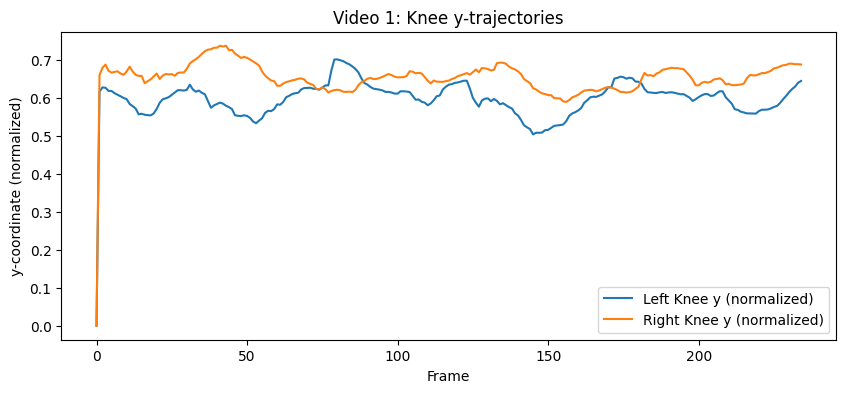

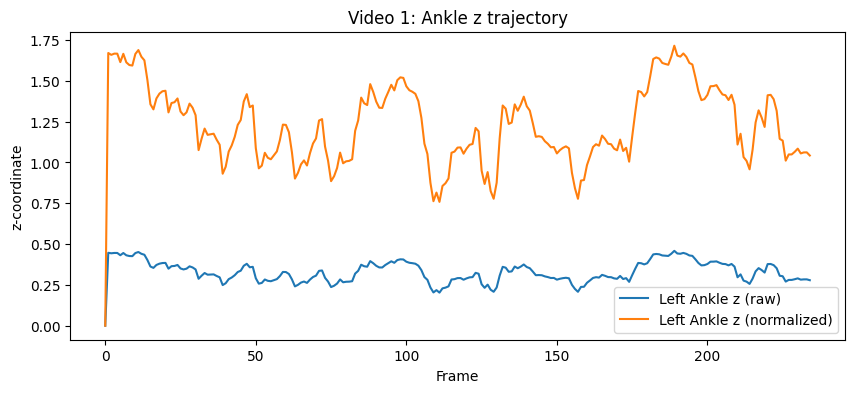

Pose min/max values after normalization:
x: -0.43922557022016423 2.1453135501965455
y: -1.3970806023349318 3.418742083138336
z: -1.755901639632202 1.756789639096466


In [84]:
#Calling Sanity check function
pose = df_video.iloc[0]['pose']  # full (T,33,3)
sanity_check_pose(pose, title="Video 1")

In [86]:
 # Pelvis should be near zero
print("Mean pelvis after normalization:",
    np.mean(pose_scaled[:, [LEFT_HIP, RIGHT_HIP]], axis=(0,1)))

Mean pelvis after normalization: [-1.08291036e-17 -9.30014783e-18 -2.76669940e-17]


In [71]:
clip = X_clips[0]  # (60, 14, 3) or (60, 33, 3)
sanity_check_pose(clip, title="First gait clip")


Checking pose of shape: (60, 14, 3)


IndexError: index 23 is out of bounds for axis 1 with size 14

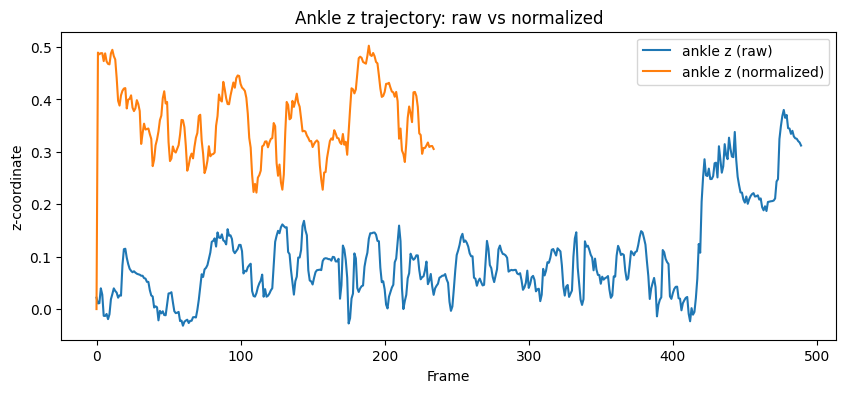

In [76]:
# c) Plot knee/ankle trajectories
# Check for sudden jumps or consistent scale:

# Example: left ankle (index 27) z-coordinate
plt.figure(figsize=(10,4))
plt.plot(pose[:, 27, 2], label="ankle z (raw)")
plt.plot(pose_scaled[:, 27, 2], label="ankle z (normalized)")
plt.xlabel("Frame")
plt.ylabel("z-coordinate")
plt.title("Ankle z trajectory: raw vs normalized")
plt.legend()
plt.show()


In [ ]:
# READY for both approaches

#Feature-based ML (XGBoost / RF)
# Example reshape for feature extraction
clip = X_clips[0]  # (60, 33, 3)

# Deep Learning
X_dl = X_clips.reshape(len(X_clips), 60, -1)


We utilized the 3D output of MediaPipe Pose (x, y, z), where the z-dimension represents relative depth. All joints were pelvis-centered and scaled by torso length to ensure comparability across subjects.

In [ ]:
                ┌───────────────┐
30fps healthy → │ Pose sequence │
60fps pathology │  (T, J, 3)    │
                └──────┬────────┘
                       │
                       ▼
           ┌─────────────────────────┐
           │  Normalize Pose 3D      │
           │  - Pelvis-centered      │
           │  - Scaled by torso      │
           │  - Works for x, y, z   │
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Detect Heel Strikes      │
           │  - Use FPS from metadata │
           │  - Convert min_time → frames
           │  - Separate left/right │
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Extract Gait-Cycle Clips│
           │  - Each clip = 1–2 cycles│
           │  - Clips may vary in length│
           │  - Filter min/max frames │
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Resample Clips           │
           │  - Fixed number of frames│
           │  - Example: 60 frames   │
           │  - Works for 30fps & 60fps│
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ Optional: Feature Calc  │
           │  - x, y, z coordinates  │
           │  - Velocity, acceleration│
           │  - Normalize by dt=1/fps│
           └─────────┬──────────────┘
                     │
                     ▼
           ┌─────────────────────────┐
           │ ML Model Input           │
           │  - Shape: (resample_frames, J*3) │
           │  - LSTM / Transformer / CNN │
           └─────────────────────────┘
